# Holistic Data Preparer

**End-to-End Data Preparation and Feature Engineering Pipeline**

This notebook integrates customer data from CSV, JSON, and SQL sources, performs data quality checks, handles missing values and outliers, applies encoding, discretization, feature construction, transformation, scaling, and prepares a final machine-learning-ready dataset.

## 1. Environment Setup & Imports

All libraries required for data loading, profiling, visualization, missing-value imputation, outlier handling, encoding, transformation, and scaling are imported here.

In [1]:
import pandas as pd
import numpy as np
import sqlite3
import json
from ydata_profiling import ProfileReport
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer,KNNImputer,IterativeImputer
import matplotlib.pyplot as  plt
import seaborn as sns
import scipy.stats as stats
from scipy.stats.mstats import winsorize
from sklearn.preprocessing  import OrdinalEncoder,LabelEncoder,OneHotEncoder,Binarizer,KBinsDiscretizer,StandardScaler,Normalizer,MinMaxScaler,MaxAbsScaler,RobustScaler,FunctionTransformer,PowerTransformer
from sklearn.compose import ColumnTransformer

## 2. Data Acquisition

### 2.1 Load Data from Multiple Sources

- CSV: main transaction data
- JSON: customer metadata
- SQL/SQLite: loan repayment history
- Merge all sources using `customer_id`

In [2]:
# Task 1: Load CSV File (Main Transactions Dataset)
df_transactions = pd.read_csv('Dataset/main_transactions.csv')
print(f"1. CSV Loaded: {df_transactions.shape[0]} rows, {df_transactions.shape[1]} columns")

# Task 2: Parse JSON File (Customer Metadata)
with open('Dataset/customer_metadata.json', 'r') as f:
    metadata_raw = json.load(f)
df_metadata = pd.DataFrame(metadata_raw)
print(f"2. JSON Parsed: {df_metadata.shape[0]} rows, {df_metadata.shape[1]} columns")

# Task 3: Fetch Records from SQL Database (Loan Repayment History)
conn = sqlite3.connect('Dataset/loan_data.db')
df_repayment = pd.read_sql_query("SELECT * FROM repayment_history", conn)
conn.close()
print(f"3. SQL Records Fetched: {df_repayment.shape[0]} rows, {df_repayment.shape[1]} columns")


# ---------------------------------------------------------
# Merging All 3 Data Sources into Single Master DataFrame
# ---------------------------------------------------------
df_master = df_transactions.merge(df_metadata, on='customer_id') \
                           .merge(df_repayment, on='customer_id')

print("\n--- Integrated Master Dataset Overview ---")
print(f"Total Shape: {df_master.shape}")
df_master.head()

1. CSV Loaded: 500 rows, 6 columns
2. JSON Parsed: 500 rows, 6 columns
3. SQL Records Fetched: 500 rows, 5 columns

--- Integrated Master Dataset Overview ---
Total Shape: (500, 15)


,customer_id,age,annual_income,loan_amount,credit_score,spending_ratio,gender,region,education_level,employment_type,join_date,loan_purpose,repayment_history,transaction_count,default_flag
0,CUST_1000,28.0,300000.0,401493.548379,720.0,27.391261,Female,East,Secondary,Self-Employed,2020-01-01,Education,5,144,1
1,CUST_1001,62.0,300000.0,339232.479301,720.0,89.785240,Female,West,Graduate,Salaried,2020-01-02,Home,5,55,0
2,CUST_1002,45.0,2500000.0,220442.159169,720.0,31.844521,Male,South,Primary,Salaried,2020-01-03,Other,1,121,1
3,CUST_1003,35.0,300000.0,674927.533040,810.0,74.795477,Female,West,Secondary,Salaried,2020-01-04,Education,4,50,0
4,CUST_1004,22.0,300000.0,94747.374341,720.0,40.380962,Female,West,Secondary,Salaried,2020-01-05,Car,5,57,1


## 3. Data Understanding

### 3.1 Dataset Structure and Data Types

In [3]:
df_master.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customer_id        500 non-null    object 
 1   age                435 non-null    float64
 2   annual_income      452 non-null    float64
 3   loan_amount        500 non-null    float64
 4   credit_score       447 non-null    float64
 5   spending_ratio     500 non-null    float64
 6   gender             484 non-null    object 
 7   region             500 non-null    object 
 8   education_level    500 non-null    object 
 9   employment_type    472 non-null    object 
 10  join_date          500 non-null    object 
 11  loan_purpose       500 non-null    object 
 12  repayment_history  500 non-null    int64  
 13  transaction_count  500 non-null    int64  
 14  default_flag       500 non-null    int64  
dtypes: float64(5), int64(3), object(7)
memory usage: 58.7+ KB


### 3.2 Descriptive Statistics

In [4]:
df_master.describe()

,age,annual_income,loan_amount,credit_score,spending_ratio,repayment_history,transaction_count,default_flag
count,435.000000,4.520000e+02,5.000000e+02,447.000000,500.000000,500.000000,500.000000,500.000000
mean,36.882759,1.064159e+06,2.542234e+05,640.201342,48.596960,2.598000,75.886000,0.200000
std,11.246609,1.749488e+06,1.984404e+05,118.955487,26.083451,1.640054,41.970753,0.400401
min,22.000000,3.000000e+05,5.000233e+04,350.000000,5.020433,0.000000,5.000000,0.000000
25%,28.000000,5.000000e+05,1.101708e+05,580.000000,26.253135,1.000000,38.000000,0.000000
50%,35.000000,5.000000e+05,1.893731e+05,650.000000,47.011700,3.000000,79.000000,0.000000
75%,45.000000,8.000000e+05,3.421236e+05,720.000000,71.842592,4.000000,114.000000,0.000000
max,62.000000,1.000000e+07,1.275765e+06,810.000000,94.616101,5.000000,149.000000,1.000000


## 4. Data Quality Assessment

### 4.1 Missing Value Analysis

In [5]:
# check Missing Values
missing_summary= pd.DataFrame({
    "Missing_Count":df_master.isnull().sum(),
    "Missing_Percentage":(df_master.isnull().mean() *100).round(2)
})

missing_summary = missing_summary[
    missing_summary["Missing_Count"]>0
].sort_values("Missing_Count",ascending=False)

display(missing_summary)

,Missing_Count,Missing_Percentage
age,65,13.0
credit_score,53,10.6
annual_income,48,9.6
employment_type,28,5.6
gender,16,3.2


### 4.2 Automated Data Quality Profiling

In [6]:
profile = ProfileReport(
    df_master,
    title="Holistic Data Preoarer  -  Data Quality Report",
    explorative=True
)

profile.to_file("Data_quality_report.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|█████████████████████████████████████████████████████████████████████████████████| 15/15 [00:00<00:00, 326.42it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

## 5. Missing Data Handling

A cleaned copy of the master dataset is created. Different imputation strategies are demonstrated according to the variable and method: median, most-frequent, random-sample imputation with a missing indicator, KNN imputation, iterative/MICE imputation, and final complete-case analysis.

In [7]:
# Separate  DataFreame  copy for  clean
df_cleaned = df_master.copy()

# ----------------------------------------------------
# 1. Simple Imputer (Numerical: Median) -> 'age'
# ----------------------------------------------------
num_imputer  = SimpleImputer(strategy="median")
df_cleaned["age"] = num_imputer.fit_transform(df_cleaned[["age"]])

# ----------------------------------------------------
# 2. Simple Imputer (Categorical: Most Frequent) -> 'employment_type'
# ----------------------------------------------------
cat_imputer = SimpleImputer(strategy="most_frequent")
df_cleaned[["employment_type"]] = cat_imputer.fit_transform(df_cleaned[["employment_type"]])

# ----------------------------------------------------
# 3. Most Frequent Category Imputation -> 'gender'
# ---------------------------------------------------
mode_gender = df_cleaned["gender"].mode()[0]
df_cleaned["gender"]=df_cleaned["gender"].fillna(mode_gender)

# ----------------------------------------------------
# 4. Missing Indicator + Random Sample Imputation -> 'annual_income'
# ----------------------------------------------------
# step 1: Missing Indicator Column
df_cleaned["annual_income_isna"] = df_cleaned["annual_income"].isnull().astype(int)

# step 2: Random Sammple Imputation
non_null_income = df_cleaned["annual_income"].dropna()
random_sample = non_null_income.sample(df_cleaned["annual_income"].isnull().sum(),random_state=42)
random_sample.index  = df_cleaned[df_cleaned["annual_income"].isnull()].index
df_cleaned.loc[df_cleaned["annual_income"].isnull(),"annual_income"]=random_sample

# ----------------------------------------------------
# 5. KNN Imputer (Multivariate) -> 'credit_score'
# ----------------------------------------------------
knn_imputer = KNNImputer(n_neighbors=5)
df_cleaned["credit_score"] = knn_imputer.fit_transform(df_cleaned[["credit_score"]])

# ----------------------------------------------------
# 6. MICE Algorithm (IterativeImputer) -> 'loan_amount' & 'credit_score'
# ----------------------------------------------------
mice_imputer = IterativeImputer(max_iter=10,random_state=42)
df_cleaned[["loan_amount","credit_score"]] = mice_imputer.fit_transform(df_cleaned[["loan_amount","credit_score"]])

# ----------------------------------------------------
# 7. Complete Case Analysis (CCA: Dropping rows with remaining NaNs)
# ----------------------------------------------------
print(f"shape before CCA: {df_cleaned.shape}")
df_cleaned.dropna(inplace=True)
print(f"shape after CCA: {df_cleaned.shape}")


shape before CCA: (500, 16)
shape after CCA: (472, 16)


### 5.1 Missing Value Verification

In [8]:
display(pd.DataFrame({
    'Missing_Count': df_cleaned.isnull().sum(),
    'Missing_Percentage': (df_cleaned.isnull().mean() * 100).round(2)
}).query('Missing_Count > 0'))

,Missing_Count,Missing_Percentage


## 6. Outlier Detection & Treatment

### 6.1 Identify Numeric Features

In [9]:
numric_cols= df_cleaned.select_dtypes(include = "number").columns
print(numric_cols)

Index(['age', 'annual_income', 'loan_amount', 'credit_score', 'spending_ratio',
       'repayment_history', 'transaction_count', 'default_flag',
       'annual_income_isna'],
      dtype='object')


### 6.2 Visual Outlier Inspection — Boxplots

In [10]:
%matplotlib inline

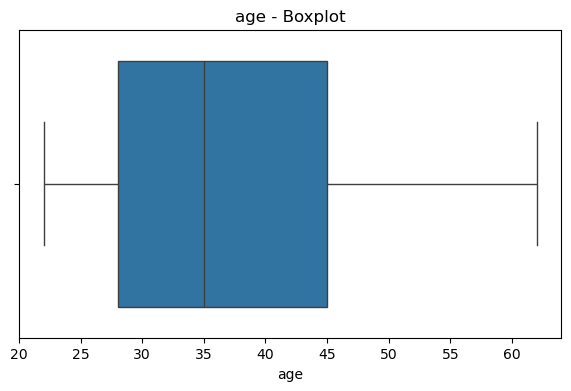

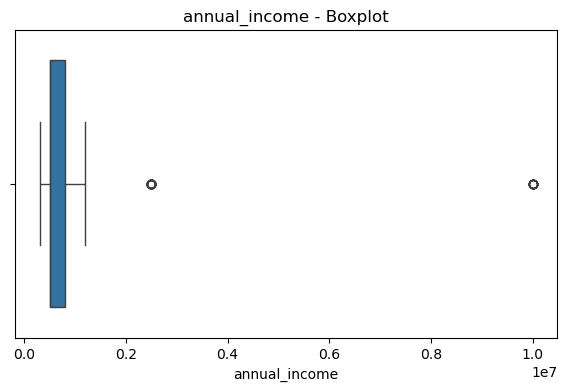

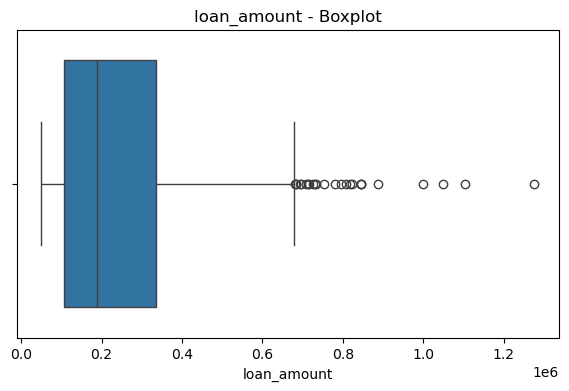

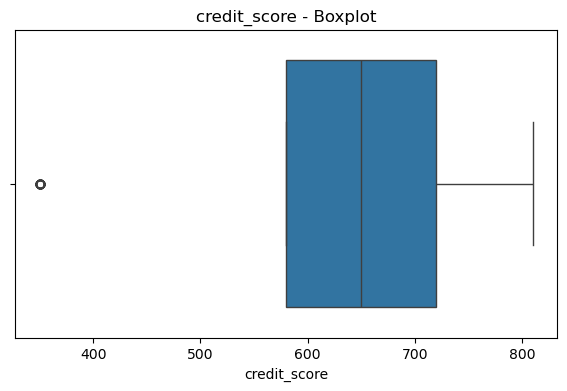

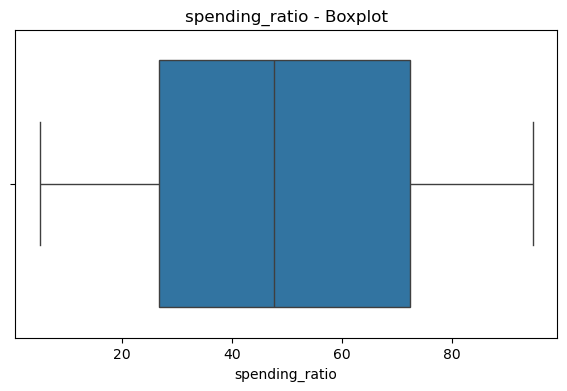

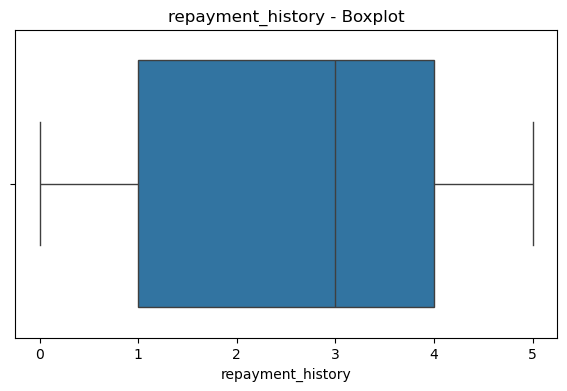

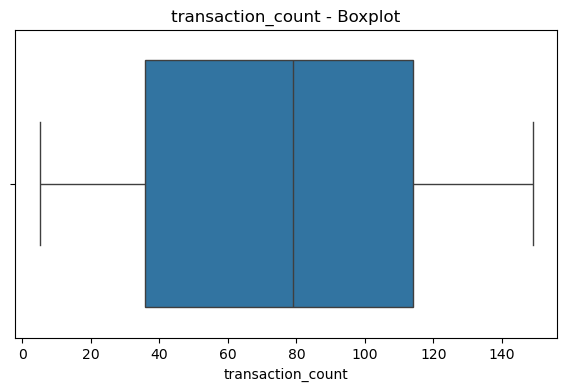

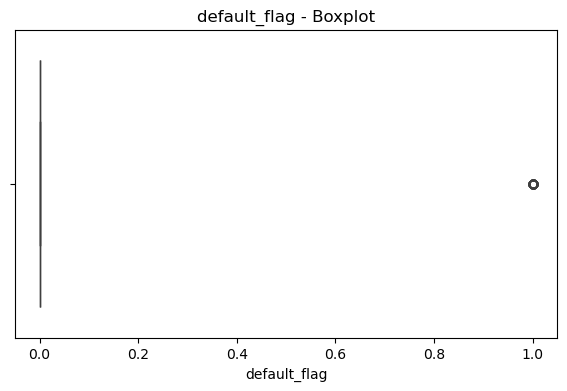

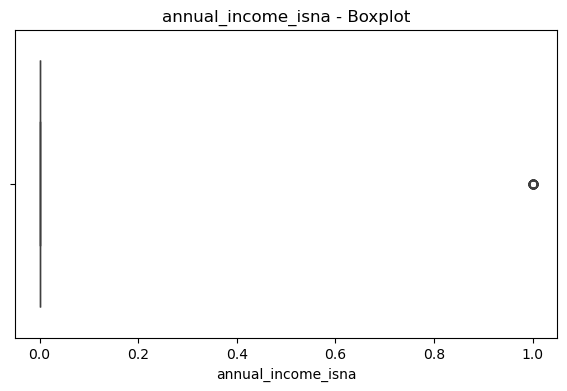

In [11]:
for column in numric_cols:
    plt.figure(figsize = (7,4))
    sns.boxplot(
        x=df_cleaned[column]
    )
    plt.title(f"{column} - Boxplot")
    plt.xlabel(column)
    plt.show()

### 6.3 Compare Outlier Detection Methods

The notebook compares Z-score, IQR, percentile, and winsorization-based detection before selecting IQR capping for the final cleaned dataset.

In [12]:
# clean Dataset copy
df_outlier = df_cleaned.copy()
num_cols = ["annual_income","loan_amount","credit_score","spending_ratio"]

# outliers count
outlier_summary = []

for col in num_cols:
    # 1:Z_score method
    z_score = np.abs(stats.zscore(df_outlier[col]))
    z_outliers = np.sum(z_score>3)

    # IQR Method
    Q1= df_outlier[col].quantile(0.25)
    Q3= df_outlier[col].quantile(0.75)
    IQR= Q3-Q1
    iqr_outliers = np.sum((df_outlier[col] < (Q1 - 1.5 * IQR)) | 
                          (df_outlier[col] > (Q3 + 1.5 * IQR)))

    # Percentile method (1% & 99%)
    p_low , p_high = df_outlier[col].quantile(0.01),df_outlier[col].quantile(0.99)
    p_outliers = np.sum((df_outlier[col] < p_low) |
                        (df_outlier[col] > p_high))

    # winsorization (5% both end)
    win_data = winsorize(df_outlier[col],limits=[0.05,0.05])
    win_changed = np.sum(df_outlier[col] != win_data)

    outlier_summary.append({
        "feature":col,
        "Z_score (>3)":z_outliers,
        "IQR Methord":iqr_outliers,
        "Percentile (1%-99%)":p_outliers,
        "winsorization (5%)":win_changed
    })

# comparion Table Display
outlier_df = pd.DataFrame(outlier_summary)
print("====================== OUTLIER DETECTION COMMPARISON =========================")
display(outlier_df)

====================== OUTLIER DETECTION COMMPARISON =========================


,feature,Z_score (>3),IQR Methord,Percentile (1%-99%),winsorization (5%)
0,annual_income,14,48,0,14
1,loan_amount,5,25,10,46
2,credit_score,0,44,0,0
3,spending_ratio,0,0,10,46


### 6.4 Apply Final Outlier Treatment

In [13]:
# ----------------------------------------------------
# FINAL OUTLIER TREATMENT (Applying on Dataset)
# ----------------------------------------------------

for col in num_cols:
    # Bast: Capping using IQR or final cleaned Dataset
    Q1 = df_outlier[col].quantile(0.25)
    Q3 = df_outlier[col].quantile(0.75)
    IQR = Q3-Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df_outlier[col] = df_outlier[col].clip(lower = lower ,upper = upper)

print("\nFinal Capping Done on All Numerical Columns!")


Final Capping Done on All Numerical Columns!


### 6.5 Validate Outlier Treatment

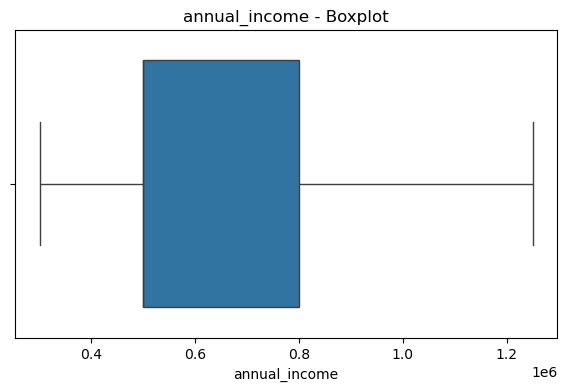

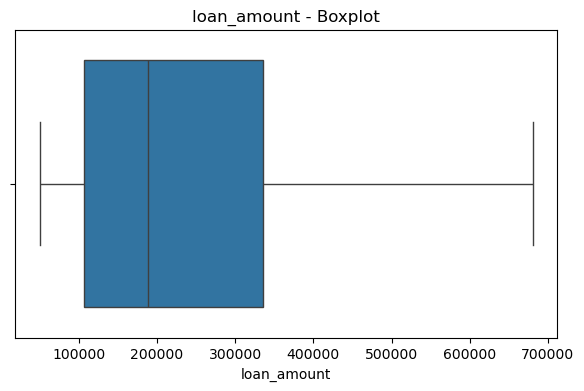

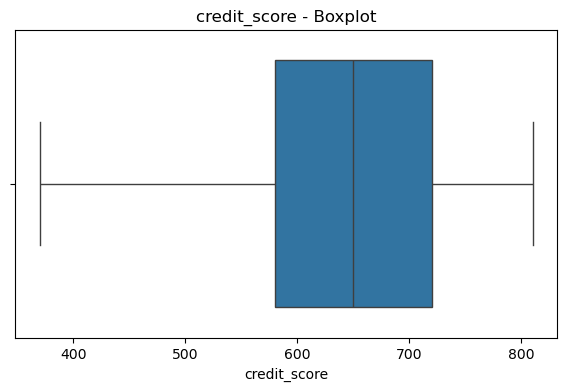

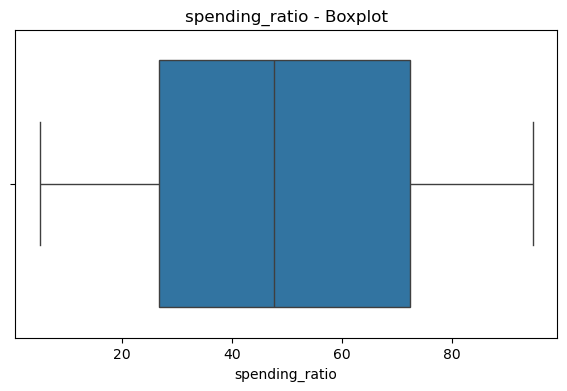

In [14]:
# Final Check by use Box plot
for column in num_cols:
    plt.figure(figsize = (7,4))
    sns.boxplot(
        x=df_outlier[column]
    )
    plt.title(f"{column} - Boxplot")
    plt.xlabel(column)
    plt.show()

## 7. Feature Engineering

### 7.1 Data Type and Date Features

In [15]:
df_fe = df_outlier.copy()

# =========================================================
# 1. HANDLING VARIABLE TYPES
# =========================================================

# gender (category)
df_fe["gender"] = df_fe["gender"].astype("category")

# Date handling
df_fe["join_date"] = pd.to_datetime(df_fe["join_date"])
df_fe["join_year"] = df_fe["join_date"].dt.year
df_fe["join_month"] = df_fe["join_date"].dt.month
df_fe["join_weekday"] = df_fe["join_date"].dt.weekday

### 7.2 Categorical Encoding

- Ordinal encoding for `education_level`
- Label encoding for `gender`
- One-hot encoding for `region`, `loan_purpose`, and `employment_type`

In [16]:
# =========================================================
# 2. ENCODING CATEGORICAL VARIABLES
# =========================================================

# Ordinal Encoding (education_level)
edu_order = [["Primary", "Secondary", "Graduate", "Post-Graduate"]]
ordinal_enc = OrdinalEncoder(categories=edu_order)
df_fe["education_level_encoded"] = ordinal_enc.fit_transform(df_fe[["education_level"]])

# Label Encoding (gender)
label_enc = LabelEncoder()
df_fe["gender_encoded"] = label_enc.fit_transform(df_fe["gender"])

# One-Hot Encoding (region, loan_purpose, employment_type)
ohe = OneHotEncoder(sparse_output=False, drop="first")
ohe_cols = ["region", "loan_purpose", "employment_type"]
ohe_encoded = ohe.fit_transform(df_fe[ohe_cols])

ohe_df = pd.DataFrame(
    ohe_encoded,
    columns=ohe.get_feature_names_out(ohe_cols),
    index=df_fe.index
)
df_fe = pd.concat([df_fe, ohe_df], axis=1)

### 7.3 Discretization & Binarization

Continuous/discrete variables are converted into bins or binary indicators where appropriate.

In [17]:
# =========================================================
# 3. NUMERICAL ENCODING & BINNING
# =========================================================

# Binning (annual_income)
income_bins = [0, 400000, 800000, 1500000, np.inf]
income_labels = [0, 1, 2, 3]
df_fe["annual_income_binned"] = pd.cut(
    df_fe["annual_income"], bins=income_bins, labels=income_labels
)

# Binning (repayment_history)
repayment_labels = [0, 1, 2]
df_fe["repayment_history_binned"] = pd.cut(
    df_fe["repayment_history"], bins=3, labels=repayment_labels
)

# Binarization (credit_score > 700)
binarizer = Binarizer(threshold=700)
df_fe["credit_score_gt_700"] = binarizer.fit_transform(df_fe[["credit_score"]])

# Quantile Binning (transaction_count)
quantile_bin = KBinsDiscretizer(
    n_bins=4, encode="ordinal", strategy="quantile"
)
df_fe["transaction_count_quantile"] = quantile_bin.fit_transform(
    df_fe[["transaction_count"]]
)

### 7.4 Remove Redundant Raw Categorical/Identifier Columns

In [18]:
raw_columns_to_drop = [
    "education_level", "gender", "region", "loan_purpose",
    "join_date", "customer_id", "annual_income_isna", "employment_type"
]

df_fe_cleaned = df_fe.drop(columns=raw_columns_to_drop)
display(df_fe_cleaned.head())

,age,annual_income,loan_amount,credit_score,spending_ratio,repayment_history,transaction_count,default_flag,join_year,join_month,...,loan_purpose_Car,loan_purpose_Education,loan_purpose_Home,loan_purpose_Other,employment_type_Self-Employed,employment_type_Unemployed,annual_income_binned,repayment_history_binned,credit_score_gt_700,transaction_count_quantile
0,28.0,300000.0,401493.548379,720.0,27.391261,5,144,1,2020,1,...,0.0,1.0,0.0,0.0,1.0,0.0,0,2,1.0,3.0
1,62.0,300000.0,339232.479301,720.0,89.785240,5,55,0,2020,1,...,0.0,0.0,1.0,0.0,0.0,0.0,0,2,1.0,1.0
2,45.0,1250000.0,220442.159169,720.0,31.844521,1,121,1,2020,1,...,0.0,0.0,0.0,1.0,0.0,0.0,2,0,1.0,3.0
3,35.0,300000.0,674927.533040,810.0,74.795477,4,50,0,2020,1,...,0.0,1.0,0.0,0.0,0.0,0.0,0,2,1.0,1.0
4,22.0,300000.0,94747.374341,720.0,40.380962,5,57,1,2020,1,...,1.0,0.0,0.0,0.0,0.0,0.0,0,2,1.0,1.0


## 8. Feature Construction & Transformation

### 8.1 Domain-Specific Feature Construction

In [19]:
df_g = df_fe_cleaned.copy()

# =========================================================
# 1. FEATURE CONSTRUCTION (New domain-specific features)
# =========================================================

df_g["debt_to_income_ratio"] = df_g["loan_amount"] / (df_g["annual_income"] + 1)
df_g["avg_monthly_transactions"] = df_g["transaction_count"] / 6
df_g["spending_to_income_ratio"] = (df_g["spending_ratio"] / 100) * df_g["annual_income"]

### 8.2 Mathematical Feature Transformations

Log, square-root, and Yeo-Johnson transformations are demonstrated to change feature distributions and improve suitability for downstream ML algorithms.

In [20]:
# =========================================================
# 2. TRANSFORMATIONS (Making features more suitable for ML)
# =========================================================

log_transformer = FunctionTransformer(np.log1p, validate=True)
sqrt_transformer = FunctionTransformer(np.sqrt, validate=True)

df_g["spending_ratio_log"] = log_transformer.fit_transform(df_g[["spending_ratio"]])
df_g["spending_ratio_sqrt"] = sqrt_transformer.fit_transform(df_g[["spending_ratio"]])

pt_yj = PowerTransformer(method="yeo-johnson")
df_g[["loan_amount_yj", "annual_income_yj"]] = pt_yj.fit_transform(
    df_g[["loan_amount", "annual_income"]]
)

### 8.3 ColumnTransformer Demonstration

An end-to-end `ColumnTransformer` is demonstrated for combining multiple numerical transformations. The resulting array is kept as a transformation example and is not used in the final feature selection below.

In [21]:
# =========================================================
# 3. COLUMN TRANSFORMER (End-to-End Transformation Example)
# =========================================================

numeric_features = ["annual_income", "loan_amount", "credit_score", "spending_ratio"]

pipeline_transformer = ColumnTransformer(
    transformers=[
        ("num_scaling", StandardScaler(), ["annual_income", "loan_amount"]),
        ("num_power_transform", PowerTransformer(method="yeo-johnson"),
         ["annual_income", "loan_amount", "spending_ratio"]),
        ("log_transform", FunctionTransformer(np.log1p), ["spending_ratio"])
    ],
    remainder="passthrough"
)

transformed_array = pipeline_transformer.fit_transform(df_g[numeric_features])
print("ColumnTransformer output shape:", transformed_array.shape)

ColumnTransformer output shape: (472, 7)


## 9. Feature Scaling

Different scaling techniques are demonstrated for continuous numerical variables. This section is primarily a **scaling comparison/feature preparation demonstration**; the final dataset selection below uses the transformed features from `df_g` rather than these scaled copies.

### 9.1 Standardization (Z-score)

In [22]:
df_scaling = df_fe_cleaned.copy()
continuous_numeric_cols = ['annual_income', 'loan_amount', 'credit_score', 'spending_ratio', 'transaction_count']

# ---------------------------------------------------------
# 1. Standardization (Z-score scaling) -> annual_income, loan_amount
# ---------------------------------------------------------
std_scaler = StandardScaler()
std_cols= ["annual_income","loan_amount"]

df_scaling[[f"{c}_std" for c in std_cols]] = std_scaler.fit_transform(df_scaling[std_cols])

# ---------------------------------------------------------
# B. MinMax Scaling (Range [0, 1]) -> All Continuous Numeric Columns
# ---------------------------------------------------------
minmax_scaler = MinMaxScaler()
df_minmax = pd.DataFrame(
    minmax_scaler.fit_transform(df_scaling[continuous_numeric_cols]),
    columns = [f"{c}_minmax" for c in continuous_numeric_cols],
    index=df_scaling.index
)

# ---------------------------------------------------------
# C. MaxAbs Scaling (Range [-1, 1]) -> All Continuous Numeric Columns
# ---------------------------------------------------------
maxabs_scaler  = MaxAbsScaler()
df_maxabs = pd.DataFrame(
    maxabs_scaler.fit_transform(df_scaling[continuous_numeric_cols]),
    columns=[f"{c}_maxabs" for c in continuous_numeric_cols],
    index=df_scaling.index
)

# ---------------------------------------------------------
# D. Robust Scaling (IQR Based) -> All Continuous Numeric Columns
# ---------------------------------------------------------
robust_scaler=RobustScaler()
df_robust = pd.DataFrame(
    robust_scaler.fit_transform(df_scaling[continuous_numeric_cols]),
    columns = [f"{c}_robust" for c in continuous_numeric_cols],
    index=df_scaling.index
)

# combine
df_scaling = pd.concat([df_scaling,df_minmax,df_maxabs,df_robust],axis=1)

df_scaling.head()

,age,annual_income,loan_amount,credit_score,spending_ratio,repayment_history,transaction_count,default_flag,join_year,join_month,...,annual_income_maxabs,loan_amount_maxabs,credit_score_maxabs,spending_ratio_maxabs,transaction_count_maxabs,annual_income_robust,loan_amount_robust,credit_score_robust,spending_ratio_robust,transaction_count_robust
0,28.0,300000.0,401493.548379,720.0,27.391261,5,144,1,2020,1,...,0.24,0.590009,0.888889,0.289499,0.966443,-0.666667,0.926729,0.500000,-0.443253,0.830671
1,62.0,300000.0,339232.479301,720.0,89.785240,5,55,0,2020,1,...,0.24,0.498514,0.888889,0.948943,0.369128,-0.666667,0.655412,0.500000,0.922460,-0.306709
2,45.0,1250000.0,220442.159169,720.0,31.844521,1,121,1,2020,1,...,1.00,0.323948,0.888889,0.336566,0.812081,2.500000,0.137755,0.500000,-0.345777,0.536741
3,35.0,300000.0,674927.533040,810.0,74.795477,4,50,0,2020,1,...,0.24,0.991830,1.000000,0.790515,0.335570,-0.666667,2.118281,1.142857,0.594356,-0.370607
4,22.0,300000.0,94747.374341,720.0,40.380962,5,57,1,2020,1,...,0.24,0.139235,0.888889,0.426787,0.382550,-0.666667,-0.409989,0.500000,-0.158927,-0.281150


## 10. Final Feature Selection & ML Dataset

### 10.1 Select Final Features

Only the cleaned, engineered, and transformed features required for the ML dataset are retained, along with the target variable `default_flag`.

In [23]:
# 1. Best Processed Numerical Features choose karte hain
selected_features = [
    # Cleaned & Engineered Continuous Features
    'annual_income_yj',          
    'loan_amount_yj',            
    'spending_ratio_log',       
    'credit_score_gt_700',       
    'avg_monthly_transactions',  
    'debt_to_income_ratio',     
    
  
    'join_year',
    'join_month',
    'join_weekday',
    

    'education_level_encoded',
    'gender_encoded',
    
    # One-Hot Encoded Columns (Region & Loan Purpose)
    *[col for col in df_g.columns if col.startswith(('region_', 'loan_purpose_'))],
    
    # Target Variable
    'default_flag'
]

# 2. Final Cleaned DataFrame Filter karein
df_final_ml = df_g[selected_features].copy()

# 3. Shape aur Null Values Check
print("=== FINAL ML DATASET SUMMARY ===")
print(f"Final Rows & Columns: {df_final_ml.shape}")
print(f"Total Missing Values: {df_final_ml.isnull().sum().sum()}")
print("\nFinal Selected Columns List:")
print(df_final_ml.columns.tolist())

# 4. Final Clean CSV Export
df_final_ml.to_csv("Dataset/final_cleaned_credit_risk_dataset.csv", index=False)
print("\nSuccess: 'final_cleaned_credit_risk_dataset.csv' saved successfully!")

=== FINAL ML DATASET SUMMARY ===
Final Rows & Columns: (472, 19)
Total Missing Values: 0

Final Selected Columns List:
['annual_income_yj', 'loan_amount_yj', 'spending_ratio_log', 'credit_score_gt_700', 'avg_monthly_transactions', 'debt_to_income_ratio', 'join_year', 'join_month', 'join_weekday', 'education_level_encoded', 'gender_encoded', 'region_North', 'region_South', 'region_West', 'loan_purpose_Car', 'loan_purpose_Education', 'loan_purpose_Home', 'loan_purpose_Other', 'default_flag']

Success: 'final_cleaned_credit_risk_dataset.csv' saved successfully!


### 10.2 Final Validation

Confirm that the final dataset has the expected shape, contains no missing values, and is ready for downstream machine-learning modeling.

In [24]:
print("Final dataset shape:", df_final_ml.shape)
print("Total missing values:", df_final_ml.isnull().sum().sum())
print("Duplicate rows:", df_final_ml.duplicated().sum())
display(df_final_ml.head())

Final dataset shape: (472, 19)
Total missing values: 0
Duplicate rows: 0


,annual_income_yj,loan_amount_yj,spending_ratio_log,credit_score_gt_700,avg_monthly_transactions,debt_to_income_ratio,join_year,join_month,join_weekday,education_level_encoded,gender_encoded,region_North,region_South,region_West,loan_purpose_Car,loan_purpose_Education,loan_purpose_Home,loan_purpose_Other,default_flag
0,-1.432561,1.029413,3.346081,1.0,24.000000,1.338307,2020,1,2,1.0,0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1
1,-1.432561,0.800567,4.508497,1.0,9.166667,1.130771,2020,1,3,2.0,0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0
2,1.468806,0.213602,3.491785,1.0,20.166667,0.176354,2020,1,4,0.0,1,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1
3,-1.432561,1.732671,4.328039,1.0,8.333333,2.249751,2020,1,5,1.0,0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0
4,-1.432561,-0.942789,3.722821,1.0,9.500000,0.315824,2020,1,6,1.0,0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1


## 11. Pipeline Summary

**Data Acquisition → Data Understanding → Data Quality → Missing Data Handling → Outlier Treatment → Feature Engineering → Encoding & Discretization → Feature Construction → Feature Transformation → Feature Scaling → Final Feature Selection → ML-Ready Dataset**